## Boundary optimization analysis — basic results

This notebook provides a first-pass evaluation of the CTCF-free boundary optimization results, assessing whether the designed sequences achieve the intended chromatin folding effect and characterizing the sequence-level properties of successful designs.

### Optimization task
Each optimization targets a genomic window selected for its flat insulation profile (low boundary activity) in the mouse (mm10) genome. Ledidi is used to edit a single 2,048 bp bin (one Akita bin) at the center of a 1.3 Mb sequence context, guided by a combined loss:

$$\mathcal{L} = \lambda \cdot \mathcal{L}_\text{input} + \mathcal{L}_\text{output} + \gamma \cdot \sum \text{FIMO scores}$$

where $\mathcal{L}_\text{output}$ is a masked L1 loss over the boundary region of the predicted Hi-C contact map, and the FIMO term penalizes CTCF motif matches (MA0139.1) within the edited bin. Predictions are made using Akita v2 fine-tuned on mESC Hi-C data (Hsieh 2019).

### Defining successful optimizations
A sequence is considered successfully optimized if it meets both criteria:
- **Boundary formed**: insulation score difference (edited − original) < −0.005
- **CTCF-free**: no CTCF motifs detected by FIMO (MA0139.1, p < 1e-4) in the edited bin

### Analyses and figures

1. **Success rate** — fraction of optimized windows meeting both criteria, broken down by fold and boundary strength target.

2. **Insulation score boxplot** — distribution of insulation scores before and after optimization for successful sequences. Confirms that the optimization achieves a meaningful reduction in insulation score (i.e. increased boundary strength) as intended.

3. **GC content boxplot** — distribution of GC content in the edited 2,048 bp bin before and after optimization.

4. **Predicted contact maps** — for a representative subset of successful windows, three panels are shown side by side:
   - **Before**: Akita v2 predicted Hi-C contact map for the original sequence
   - **After**: predicted map for the optimized sequence
   - **After − Before**: difference map (PiYG colormap), highlighting contacts gained (green) and lost (pink) as a result of the edits. A successful boundary design is expected to show a characteristic cross pattern — reduced contacts in the off-diagonal quadrants and a sharp insulation stripe along the central bin diagonal.

## 1. Imports

In [1]:
import os
import sys

import torch
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

from akita.model import SeqNN
from semifreddo.optimization_loop import build_stem
from utils.df_utils import simple_load_results
from utils.data_utils import from_upper_triu

## 2. Configuration

In [2]:
_PROJ = os.environ["AKITA_SF_DIR"]
BASE_DIR  = Path(f"{_PROJ}/optimizations/boundaries_no_ctcf/")
PLOTS_DIR = Path("./../plots/")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

RESULT_DIRS = ["results"]
FOLDS       = range(8)

In [3]:
df = simple_load_results(RESULT_DIRS, BASE_DIR, FOLDS, "selected_genomic_windows_centered_chrom_states_results.tsv")

df_control = simple_load_results(RESULT_DIRS, BASE_DIR, FOLDS, "selected_genomic_windows_centered_chrom_states_shuffled_control.tsv")

df = df.merge(
    df_control[["chrom", "centered_start", "centered_end", "fold", "insul_score_shuffled"]],
    on=["chrom", "centered_start", "centered_end", "fold"],
    how="left",
)

df["insul_score_diff"]     = df["insul_score_edited"] - df["insul_score_orig"]
df["has_ctcf"] = df["CTCFs_num"] > 0

# Success requires a negative diff (accounting for noise) AND zero CTCFs
df["optimization_success"] = (df["insul_score_diff"] < -0.005) & (df["CTCFs_num"] == 0)

print(f"Loaded {len(df)} windows across {df['fold'].nunique()} folds")
print(f"Successful optimizations: {df['optimization_success'].sum()} / {len(df)} ({100 * df['optimization_success'].mean():.1f}%)")

success_df = df[df["optimization_success"]].reset_index(drop=True)

Loaded 355 windows across 8 folds
Successful optimizations: 178 / 355 (50.1%)


## 3. Insulation score boxplot 

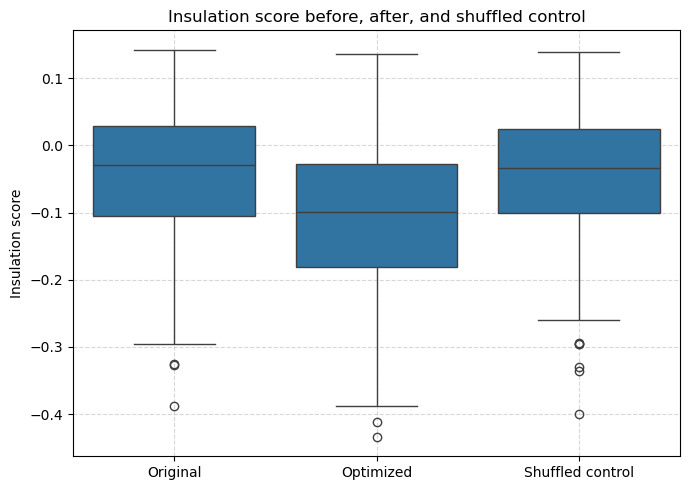

In [4]:
plot_df = pd.melt(
    success_df,
    value_vars=["insul_score_orig", "insul_score_edited", "insul_score_shuffled"],
    var_name="condition",
    value_name="insul_score",
)
plot_df["condition"] = plot_df["condition"].map({
    "insul_score_orig":     "Original",
    "insul_score_edited":   "Optimized",
    "insul_score_shuffled": "Shuffled control",
})

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data=plot_df, x="condition", y="insul_score",
    order=["Original", "Optimized", "Shuffled control"],
    ax=ax,
)
plt.grid(True, linestyle="--", alpha=0.5)
ax.set_xlabel("")
ax.set_ylabel("Insulation score")
ax.set_title("Insulation score before, after, and shuffled control")

plt.tight_layout()
# plt.savefig(f"{PLOTS_DIR}/boundary_insulation_score_boxplot.svg", format="svg")
plt.show()

## 4. GC content boxplot 

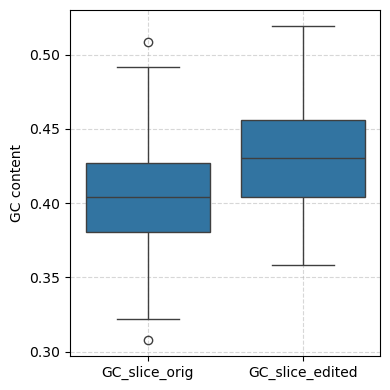

In [5]:
# --- Reshape for plotting ---
plot_df = pd.melt(
    success_df,
    value_vars=["GC_slice_orig", "GC_slice_edited"],
    var_name="condition",
    value_name="gc_content",
)

# --- Boxplot ---
plt.figure(figsize=(4, 4))
sns.boxplot(data=plot_df, x="condition", y="gc_content")

plt.ylabel("GC content")
plt.xlabel("")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
# plt.savefig(f"{PLOTS_DIR}/gc_content_boxplot.svg", format="svg")
plt.show()

## 5. Predicted contact maps

In [6]:
MODEL_PATH   = ("/home1/smaruj/akita_pytorch/models/finetuned/mouse/Hsieh2019_mESC/checkpoints/"
                "Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth")
SEQ_BASE_DIR = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/analysis/flat_regions")
GEN_BASE_DIR = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/boundaries_no_ctcf/results")

CENTER_BIN_MAP   = 256
CONTEXT_BINS     = 5
BIN_SIZE         = 2048
CROPPING_APPLIED = 64
N_TRIU           = 130305
MAP_SIZE         = 512

VMIN, VMAX = -0.6, 0.6
CMAP       = "RdBu_r"
DIFF_VMIN, DIFF_VMAX = -0.3, 0.3
DIFF_CMAP        = "PiYG"
N_EXAMPLES = 10

In [7]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = SeqNN()
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.to(device).eval()
print(f"Model loaded on {device}")

Model loaded on cuda:0


In [8]:
def predict(X: torch.Tensor) -> np.ndarray:
    """Run full Akita on X (1, 4, L) → (512, 512) 2-D contact map."""
    with torch.no_grad():
        y = model(X.to(device))          # (1, 1, N_triu)
    mat = from_upper_triu(y.squeeze().cpu().numpy(), MAP_SIZE, 2)
    return mat

In [9]:
success_df = df[df["optimization_success"]].sample(
    n=min(N_EXAMPLES, df["optimization_success"].sum()),
    random_state=42,
).reset_index(drop=True)

print(f"Plotting {len(success_df)} successful windows")

Plotting 10 successful windows


/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


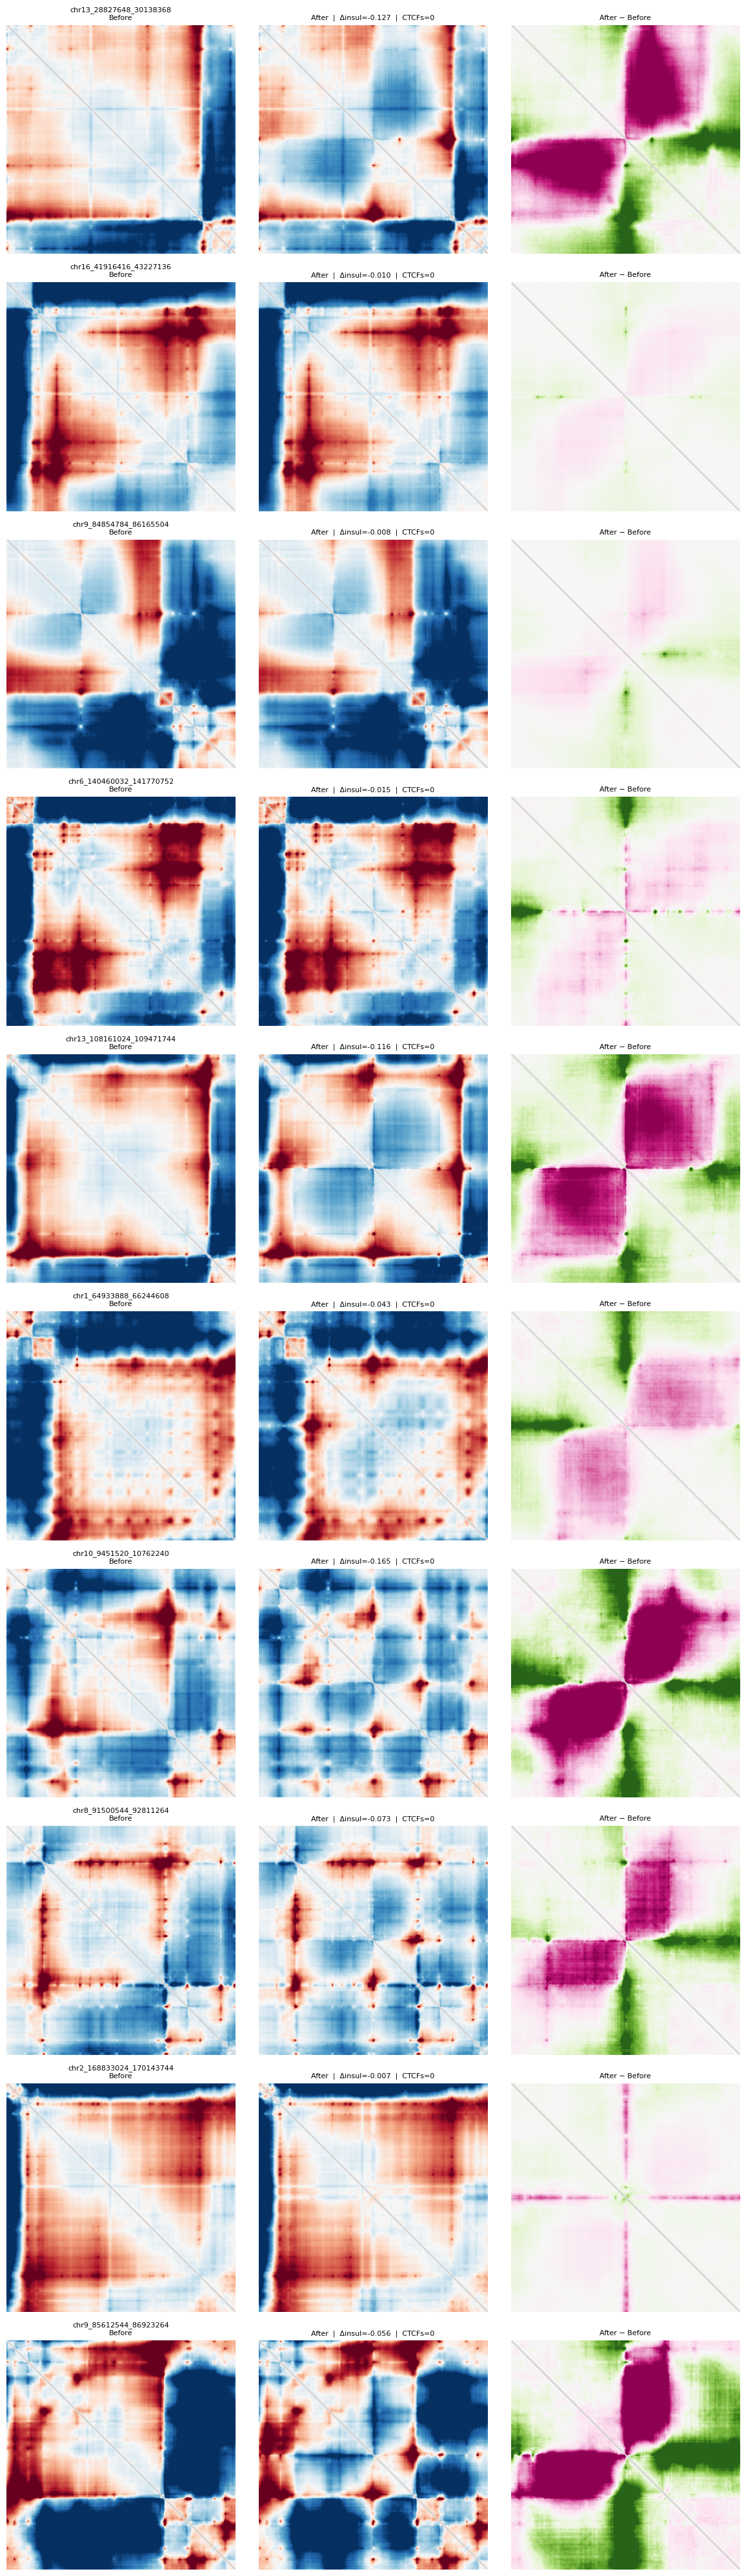

In [10]:
fig, axes = plt.subplots(
    len(success_df), 3,
    figsize=(12, 4 * len(success_df)),
    squeeze=False,
)

for idx, (i, row) in enumerate(success_df.iterrows()):
    fold  = int(row["fold"][-1])
    stem  = build_stem(row["chrom"], int(row["centered_start"]), int(row["centered_end"]))

    # Original sequence
    X_orig = torch.load(
        SEQ_BASE_DIR / f"mouse_sequences/fold{fold}/{stem}_X.pt",
        weights_only=True,
    )

    # Generated central bin — splice back into full sequence
    gen_center = torch.load(
        GEN_BASE_DIR / f"fold{fold}/{stem}_gen_seq.pt",
        weights_only=True,
    )
    X_gen = X_orig.clone()

    # Compute center bp coords the same way SemifreddoLedidiWrapper does
    center_bp_start = (CENTER_BIN_MAP + CROPPING_APPLIED) * BIN_SIZE
    center_bp_end   = center_bp_start + BIN_SIZE
    X_gen[:, :, center_bp_start:center_bp_end] = gen_center

    map_orig = predict(X_orig)
    map_gen  = predict(X_gen)

    ax_before, ax_after, ax_diff = axes[idx]

    ax_before.imshow(map_orig, vmin=VMIN, vmax=VMAX, cmap=CMAP, origin="upper")
    ax_before.set_title(f"{stem}\nBefore", fontsize=8)
    ax_before.axis("off")

    ax_after.imshow(map_gen, vmin=VMIN, vmax=VMAX, cmap=CMAP, origin="upper")
    ax_after.set_title(
        f"After  |  Δinsul={row['insul_score_diff']:.3f}  |  CTCFs={int(row['CTCFs_num'])}",
        fontsize=8,
    )
    ax_after.axis("off")

    ax_diff.imshow(map_gen - map_orig, vmin=DIFF_VMIN, vmax=DIFF_VMAX, cmap=DIFF_CMAP, origin="upper")
    ax_diff.set_title("After − Before", fontsize=8)
    ax_diff.axis("off")

plt.tight_layout()
# plt.savefig(PLOTS_DIR / "before_after_maps.svg", format="svg")
plt.show()

## Saving 100kb sequences for Puffin predictions

In [ ]:
from pyfaidx import Fasta
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.SeqIO.FastaIO import FastaWriter

In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────────
FASTA_FILE   = "/project2/fudenber_735/genomes/mm10/mm10.fa"
OUTPUT_DIR   = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/boundaries_no_ctcf/results")

OUTPUT_ORIG  = OUTPUT_DIR / "original_sequences_100kb.fasta"
OUTPUT_OPT   = OUTPUT_DIR / "optimized_sequences_100kb.fasta"


In [ ]:
# ── Constants ─────────────────────────────────────────────────────────────────
BIN_SIZE         = 2048
CROPPING_APPLIED = 64

# Central bin bp coordinates within the full sequence (same as SemifreddoLedidiWrapper)
CENTER_BP_START = (CENTER_BIN_MAP + CROPPING_APPLIED) * BIN_SIZE
CENTER_BP_END   = CENTER_BP_START + BIN_SIZE

FLANK = (100_000 - BIN_SIZE) // 2   # flanking bp on each side to reach 100kb total

In [ ]:
# ── Helpers ───────────────────────────────────────────────────────────────────
def ohe_to_seq(tensor: torch.Tensor) -> str:
    """Convert a (1, 4, L) or (4, L) one-hot tensor to a DNA string."""
    base_order = ["A", "C", "G", "T"]
    t = tensor.squeeze(0).permute(1, 0)   # → (L, 4)
    indices = torch.argmax(t, dim=1)
    return "".join(base_order[i.item()] for i in indices)


def write_fasta(records: list, path: Path) -> None:
    with open(path, "w") as f:
        writer = FastaWriter(f, wrap=None)
        writer.write_file(records)
    print(f"✅ {len(records)} sequences written to {path}")

In [ ]:
# ── Load genome and successful windows ────────────────────────────────────────
genome     = Fasta(FASTA_FILE)
success_df = df[df["optimization_success"]].reset_index(drop=True)

In [ ]:
# ── Build FASTA records ───────────────────────────────────────────────────────
orig_records = []
opt_records  = []

for _, row in success_df.iterrows():
    chrom          = row["chrom"]
    centered_start = int(row["centered_start"])
    centered_end   = int(row["centered_end"])
    fold           = int(row["fold"][-1])
    stem           = build_stem(chrom, centered_start, centered_end)

    # Absolute genomic coordinates of the central edited bin
    abs_bin_start = centered_start + CENTER_BP_START
    abs_bin_end   = centered_start + CENTER_BP_END

    # Flanking genomic sequence from reference
    upstream   = str(genome[chrom][abs_bin_start - FLANK : abs_bin_start].seq).upper()
    downstream = str(genome[chrom][abs_bin_end   : abs_bin_end + FLANK].seq).upper()

    # ── Original sequence ─────────────────────────────────────────────────────
    orig_bin = str(genome[chrom][abs_bin_start:abs_bin_end].seq).upper()
    orig_full = upstream + orig_bin + downstream
    orig_records.append(SeqRecord(
        Seq(orig_full),
        id          = f"{stem}_original",
        description = "",
    ))

    # ── Optimized sequence ────────────────────────────────────────────────────
    gen_center = torch.load(
        GEN_BASE_DIR / f"fold{fold}/{stem}_gen_seq.pt",
        weights_only=True,
    )
    opt_bin  = ohe_to_seq(gen_center)
    opt_full = upstream + opt_bin + downstream
    opt_records.append(SeqRecord(
        Seq(opt_full),
        id          = f"{stem}_optimized",
        description = "",
    ))

# ── Write ─────────────────────────────────────────────────────────────────────
write_fasta(orig_records, OUTPUT_ORIG)
write_fasta(opt_records,  OUTPUT_OPT)